<a href="https://colab.research.google.com/github/NishigandhaChoudhury/Neural-Network-and-Deep-Learning-Lab-Experiments/blob/main/NNDLLAB6(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

actual exp 4

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
# Load CIFAR-10 (downloads automatically, ~170MB)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Class indices: 2=bird, 3=cat, 5=dog
selected = [2, 3, 5]

def filter_classes(x, y, classes):
    mask = tf.reduce_any([y == c for c in classes], axis=0).numpy().flatten()
    x_f = x[mask]
    y_f = y[mask]
    # Remap labels to 0, 1, 2
    label_map = {2: 0, 3: 1, 5: 2}
    y_f = tf.constant([[label_map[int(v)]] for v in y_f])
    return x_f, y_f

x_train, y_train = filter_classes(x_train, y_train, selected)
x_test,  y_test  = filter_classes(x_test,  y_test,  selected)

# Normalize pixel values to 0-1
x_train = x_train / 255.0
x_test  = x_test  / 255.0

print("Train samples:", len(x_train))   # ~15,000
print("Test  samples:", len(x_test))    # ~3,000

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Train samples: 15000
Test  samples: 3000


/tmp/ipykernel_403/657961098.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_f = tf.constant([[label_map[int(v)]] for v in y_f])


In [ ]:
model = models.Sequential([
    # Conv layer 1: learns edges
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    # Conv layer 2: learns shapes
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Dense layers: classifies
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3 classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,107 (652.76 KB)

 Trainable params: 167,107 (652.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=10,
                    validation_split=0.1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5277 - loss: 0.9608 - val_accuracy: 0.6033 - val_loss: 0.8676
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6277 - loss: 0.8277 - val_accuracy: 0.6180 - val_loss: 0.8307
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6690 - loss: 0.7551 - val_accuracy: 0.6653 - val_loss: 0.7740
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7050 - loss: 0.6829 - val_accuracy: 0.6400 - val_loss: 0.8203
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7312 - loss: 0.6358 - val_accuracy: 0.6887 - val_loss: 0.7282
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7554 - loss: 0.5768 - val_accuracy: 0.6907 - val_loss: 0.7378
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7811 - loss: 0.5255 - val_accuracy: 0.7040 - val_loss: 0.7097
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8076 - loss: 0.4720 - val_accuracy: 0.

In [ ]:
loss, acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {acc:.2%}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7033 - loss: 0.8053
Test accuracy: 70.33%


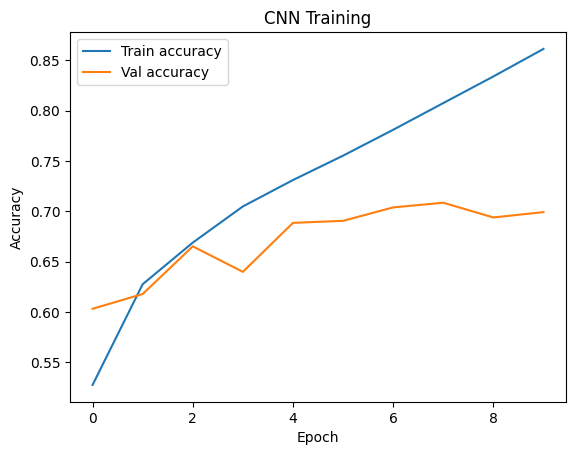

In [ ]:
plt.plot(history.history['accuracy'],    label='Train accuracy')
plt.plot(history.history['val_accuracy'],label='Val accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.title('CNN Training'); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


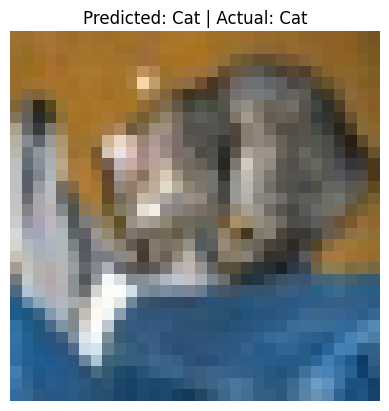

In [ ]:
class_names = ['Bird', 'Cat', 'Dog']
img = x_test[0:1]                            # pick first test image
pred = model.predict(img)
predicted = class_names[pred.argmax()]
actual    = class_names[int(y_test[0])]

plt.imshow(x_test[0])
plt.title(f"Predicted: {predicted} | Actual: {actual}")
plt.axis('off'); plt.show()